# Analysis of a Candidate Gravitationally Lensed High-Redshift Quasar

This repository contains a Python notebook developed to investigate whether a candidate high-redshift quasar is gravitationally lensed using optical and near-infrared spectroscopic observations.

The notebook performs the following tasks:

1. Data selection, cleaning, normalization to photometric measurements, and spectral binning.
2. Selection and preparation of spectral templates for spectral fitting and analysis.
3. Combination of multi-instrument observations, including FLAMINGOS-2 (near-infrared) and GMOS (optical) data obtained with the Gemini telescopes.
4. Spectral analysis aimed at characterizing the source and assessing the lensing hypothesis.

The complete scientific study also includes complementary analyses presented in a second notebook (`Quasar_P2`) and photometric investigations based on HST observations.

Due to publication restrictions, the original observational data and final figures from the associated research are not publicly available.

In [2]:
#Import libraries
import numpy as np
import matplotlib.pyplot  as plt
import os
#Astronomical libraries
import astropy
from astropy.io import fits
from photutils.aperture import aperture_photometry
from photutils.aperture import CircularAnnulus, CircularAperture, SkyCircularAperture, SkyCircularAnnulus 
from photutils.aperture import ApertureStats
from astropy.visualization import simple_norm
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u


#Import tool sculptor designed for galaxies. Code and documentation --> https://sculptor.readthedocs.io/en/latest/index.html
from sculptor import speconed as sod
from astropy import units as u

In [3]:
# Import the speconed module from sculptor
#This needs to be run for an specific previously intalled environment
from sculptor import speconed as sod
# Instantiate an empty SpecOneD object
spec = sod.SpecOneD()

In [4]:
#Open file/Open F2 data 
hdu= fits.open('spec1d_P170p20_coadd_tellcorr.fits')
#Astronomical data comes with headers with important information for analysis
hdr = hdu[0].header

In [5]:
#Rename F2 data
dataf=hdu[1].data
wavef=np.array(dataf['wave'],dtype='float')
fluxf=np.array(dataf['flux'],dtype='float')

In [6]:
#Open second dataset/GMOS data
hdu_g= fits.open('spec1d_N20220613S0020-N20220613S0025-PSO170p20.fits') #new data
hdr_g = hdu_g[0].header
print(hdu_g[1].data.columns)

ColDefs(
    name = 'TRACE_SPAT'; format = '1D'
    name = 'FWHMFIT'; format = '1D'
    name = 'OPT_WAVE'; format = '1D'
    name = 'OPT_FLAM'; format = '1D'
    name = 'OPT_FLAM_SIG'; format = '1D'
    name = 'OPT_FLAM_IVAR'; format = '1D'
    name = 'OPT_COUNTS'; format = '1D'
    name = 'OPT_COUNTS_IVAR'; format = '1D'
    name = 'OPT_COUNTS_SIG'; format = '1D'
    name = 'OPT_MASK'; format = '1L'
    name = 'OPT_COUNTS_SKY'; format = '1D'
    name = 'OPT_FRAC_USE'; format = '1D'
    name = 'OPT_CHI2'; format = '1D'
    name = 'BOX_NPIX'; format = '1D'
    name = 'BOX_WAVE'; format = '1D'
    name = 'BOX_FLAM'; format = '1D'
    name = 'BOX_FLAM_SIG'; format = '1D'
    name = 'BOX_FLAM_IVAR'; format = '1D'
    name = 'BOX_COUNTS'; format = '1D'
    name = 'BOX_COUNTS_IVAR'; format = '1D'
    name = 'BOX_COUNTS_SIG'; format = '1D'
    name = 'BOX_MASK'; format = '1L'
    name = 'BOX_COUNTS_SKY'; format = '1D'
    name = 'trace_spec'; format = '1K'
)


In [7]:
#Rename GMOS data
datag=hdu_g[1].data
waveg=datag['OPT_WAVE']
fluxg=datag['OPT_FLAM']
errorg=datag['OPT_FLAM_IVAR']

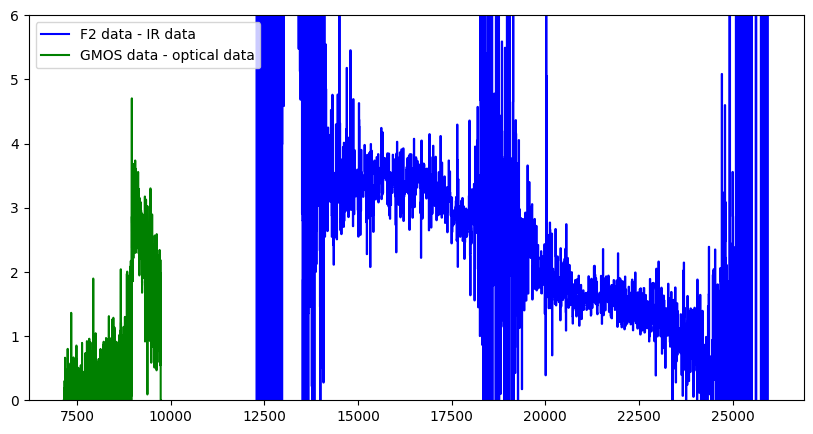

In [8]:
#Plot both datasets. Shows the raw data, 1D spectrum in both bands. Left (GMOS optical) Right (F2 NIR)
plt.figure(figsize=(10,5))
#Plot F2
plt.step(wavef,fluxf,color='blue',label='F2 data - IR data')
#Plot GMOS data
plt.step(waveg,fluxg,color='green',label='GMOS data - optical data')
#Limits of plot
plt.ylim(0,6)
plt.legend()

3422 3422


(8600.0, 8700.0)

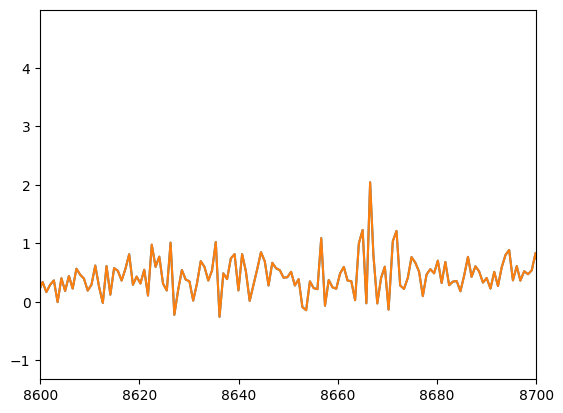

In [9]:
#Cleaning data/removing problematic points
point= ~np.isclose(waveg, 8650, atol=0)
gmosdatafluxnew=fluxg[point]
gmosdataerrnew=errorg[point]
gmosdatawavenew=waveg[point]

tabnew = astropy.table.Table()
tabnew['WAVE']= gmosdatawavenew
tabnew['FLUX']= gmosdatafluxnew
tabnew['ERR']= gmosdataerrnew

#Create a new fits file for GMOS data
tabnew.write('GMOSnew.fits', overwrite=True)

print(len(fluxg),len(gmosdatafluxnew))

#Plot new data to check the previously eliminated points
plt.plot(waveg,fluxg)
plt.plot( gmosdatawavenew,gmosdatafluxnew)
plt.xlim(8600,8700)
#plt.axvline(8650) #Here I marked a line to find a problematic point

## We build spectrum objects over SCULPTOR to analyze them.
Following the manual available in SCULPTOR webpage

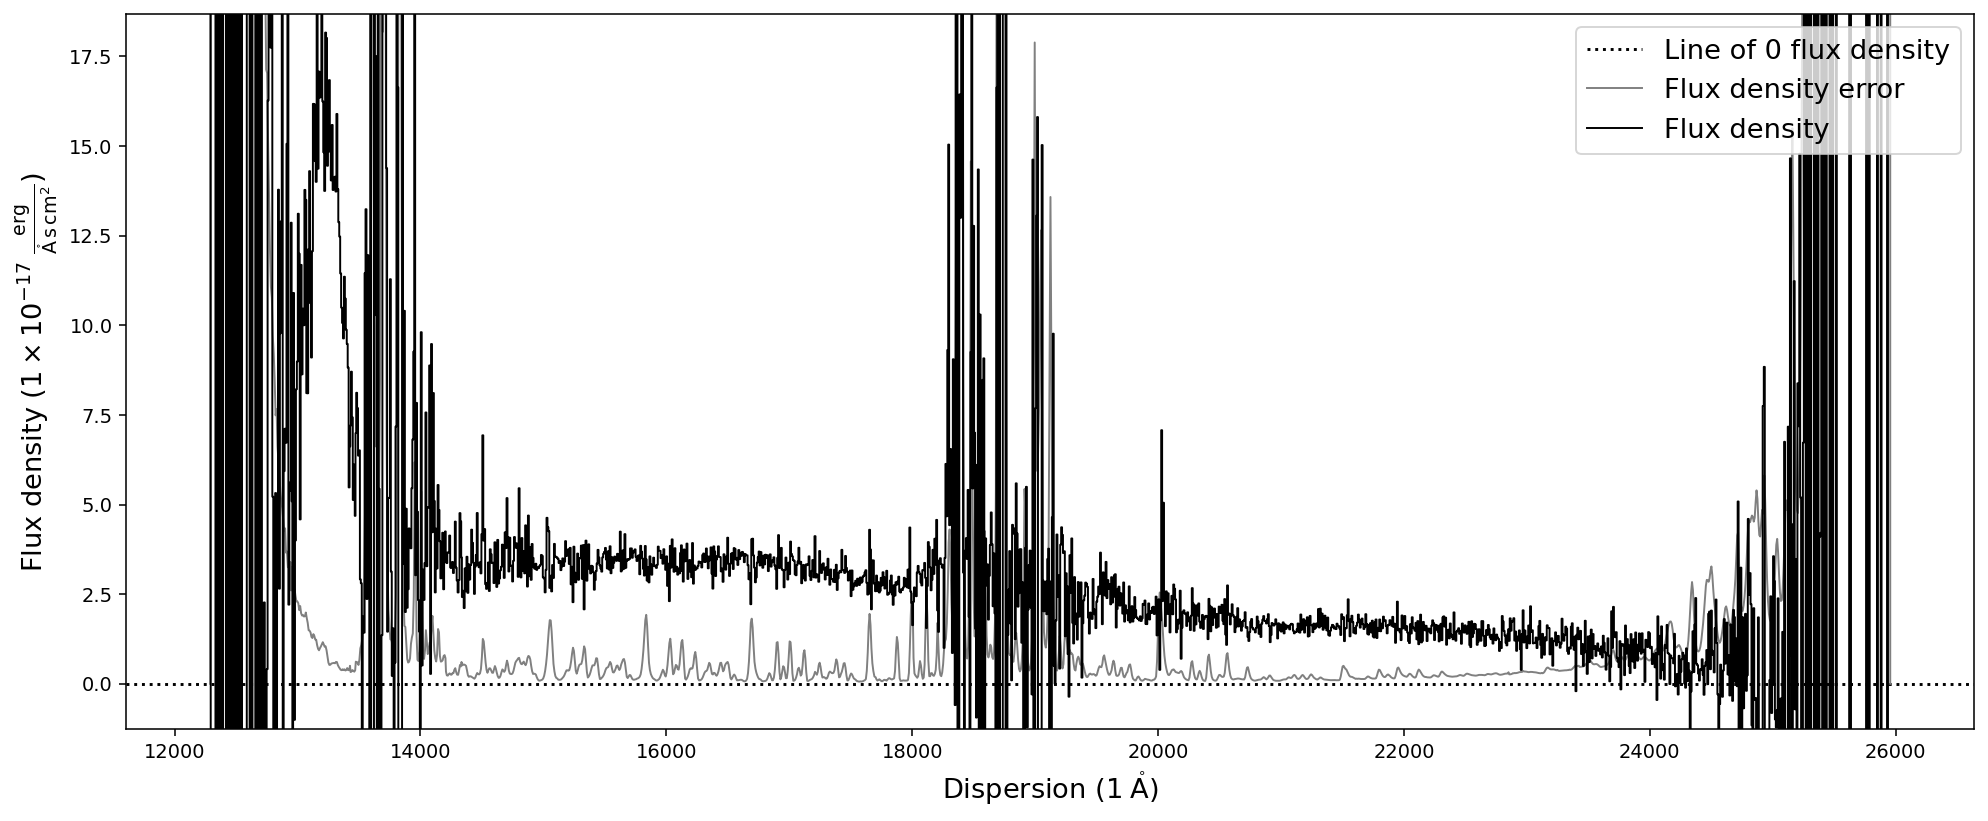

In [10]:
from astropy.io import fits
import astropy.units as units
# Define the name of the example spectrum
spec_filename = 'spec1d_P170p20_coadd_tellcorr.fits'

# Read in the example spectrum with astropyspec1d_P170p20_coadd_tellcorr.fits
hdu = fits.open(spec_filename)

# Extract the dispersion axis, the flux density and the error from the fits file
dispersion = hdu[1].data[0]  ## * u.Ang
flux_density = hdu[1].data[2]  ## * u.erg/u.s/u.cm/u.cm/u.Ang
flux_density_ivar = hdu[1].data[3] ## * u.erg/u.s/u.cm/u.cm/u.Ang

# Extract the fits header of the spectrum
header = hdu[0].header

# Before we initialize the SpecOneD object add units
dispersion_unit = 1.*units.AA
fluxden_unit = 1e-17 * units.erg/units.s/units.cm**2/units.AA

#Define astropy table
tab = astropy.table.Table(hdu[1].data)

import numpy.ma as ma

arr = tab["ivar"]
masked_arr = ma.masked_equal(arr, 0)

spec = sod.SpecOneD(dispersion=tab["wave"].data, fluxden=tab["flux"].data, fluxden_ivar=tab["ivar"].data,
                   fluxden_unit=fluxden_unit, dispersion_unit=dispersion_unit, header=header)
spec.plot()

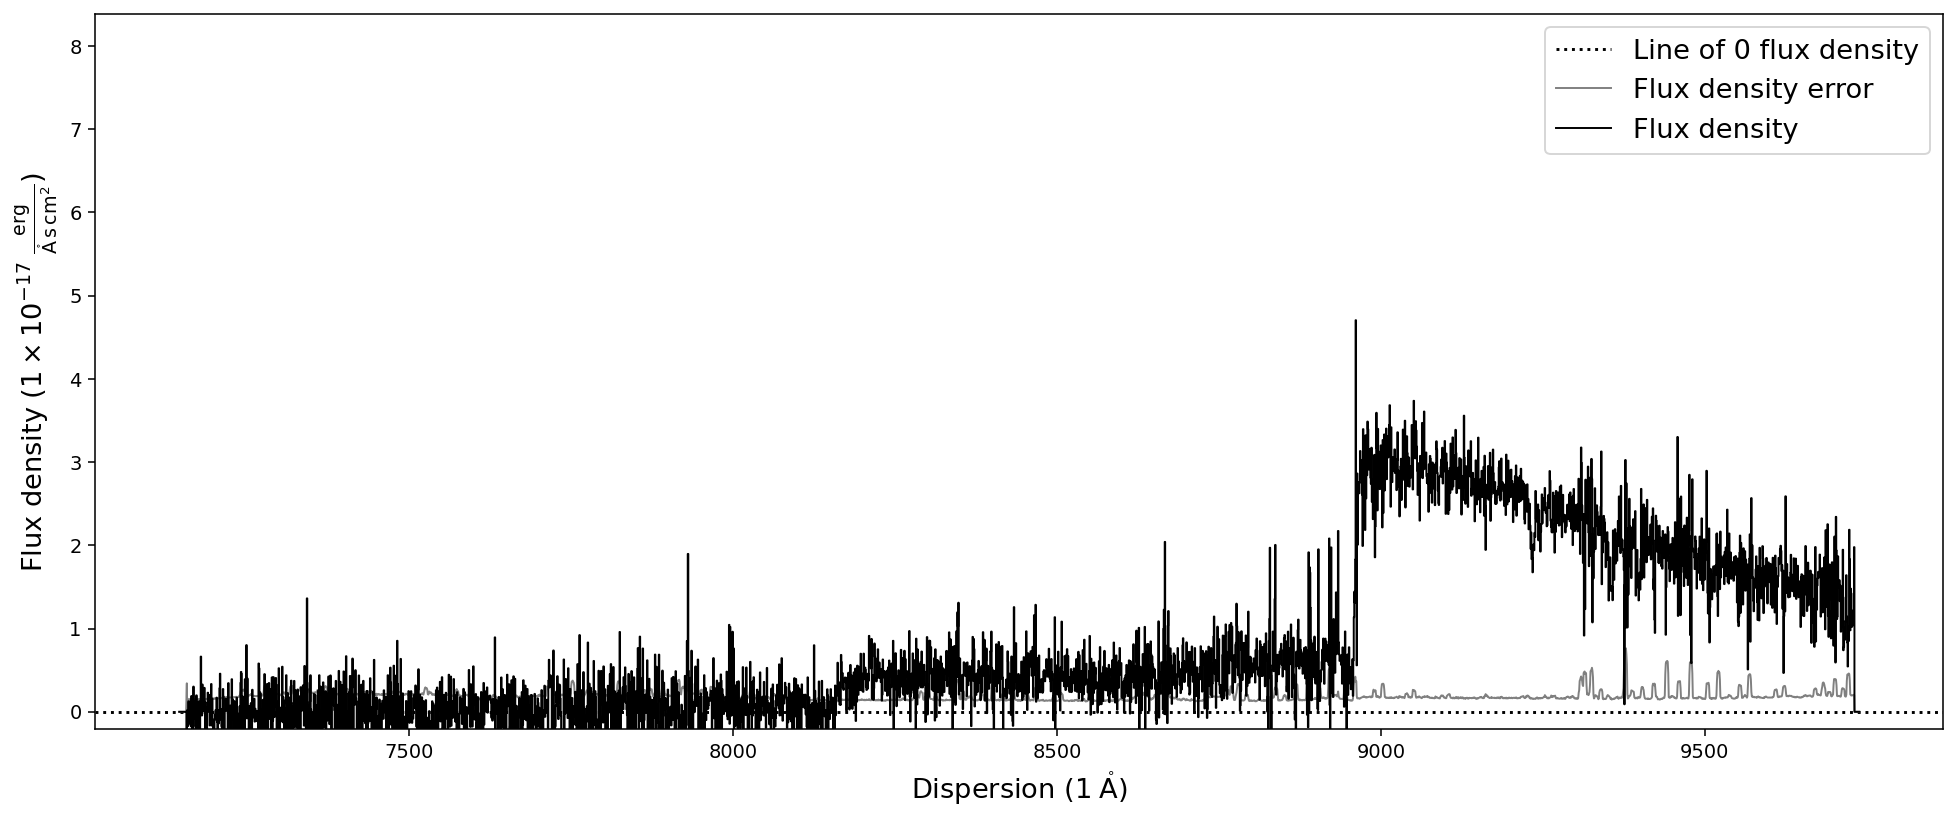

20.350169231051275


In [11]:
#Here we convert our data to an spectrum using SCULPTOR. 
# Define the name of the example spectrum
spec_filename2 = 'GMOSnew.fits' 

# Read in the example spectrum with astropy
hdu = fits.open(spec_filename2)

# Extract the dispersion axis, the flux density and the error from the fits file
dispersion = hdu[1].data[0]  
flux_density = hdu[1].data[1]  
flux_density_ivar = hdu[1].data[2] 

# Extract the fits header of the spectrum
header = hdu[0].header

# Before we initialize the SpecOneD object add units

dispersion_unit = 1.*units.AA
fluxden_unit = 1e-17 * units.erg/units.s/units.cm**2/units.AA

#Define astropy table
tab2 = astropy.table.Table(hdu[1].data)

arr = tab["ivar"]
masked_arr = ma.masked_equal(arr, 0)

spec2 = sod.SpecOneD(dispersion=tab2["WAVE"].data, fluxden=tab2["FLUX"].data, fluxden_ivar=tab2['ERR'].data,
                   fluxden_unit=fluxden_unit, dispersion_unit=dispersion_unit, header=header)
spec2.plot()
pb = sod.PassBand('PS1-z')
print(spec2.calculate_passband_ab_magnitude(pb, force=False, match_method='interpolate'))

# Resample data. 
The smallest pixel size will be used to create bins of the same size over all of our data (F2 and GMOS)

In [12]:
#Here we check pixel size. The smallest pixel size will be used to create bins of the same size over all of our data (F2 and GMOS).
#GMOS pixel size
pixel=spec2.dispersion-np.roll(spec2.dispersion,-1)
print(pixel[10:100])

[-0.75827947 -0.75827947 -0.75827947 -0.75827947 -1.09570622 -0.18093134
 -0.96706546 -0.69601421 -0.76185103 -0.79619163 -0.76998736 -0.72951387
 -0.7932441  -0.78488174 -0.76118807 -0.76303101 -0.75639688 -0.78242319
 -0.763943   -0.76009781 -0.75962146 -0.77750109 -0.77307319 -0.75796329
 -0.76425785 -0.77053515 -0.77824675 -0.76865883 -0.74417948 -0.77413388
 -0.78071882 -0.74211523 -0.76260602 -0.75378892 -0.77479659 -0.77915802
 -0.75420116 -0.75561023 -0.77353368 -0.77096086 -0.75478513 -0.75443872
 -0.76937055 -0.77102414 -0.74569615 -0.76254162 -0.76685057 -0.76512362
 -0.75348239 -0.76922758 -0.74895901 -0.76615058 -0.7511743  -0.7573189
 -0.75442365 -0.76707929 -0.75170153 -0.75458023 -0.75462918 -0.76208774
 -0.75495139 -0.75455901 -0.75842682 -0.75455792 -0.75414284 -0.75535307
 -0.75521898 -0.75387832 -0.7561561  -0.75416352 -0.75631803 -0.75673462
 -0.75242401 -0.75377305 -0.75614024 -0.75289058 -0.75292418 -0.75590263
 -0.75631778 -0.75508501 -0.75471948 -0.75510941 -0.

In [13]:
#FLAMINGOS pixel size
pixelf=spec.dispersion-np.roll(spec.dispersion,-1)
print(np.mean(pixelf[10:100]))

-7.526435372296995


### We will use the pixel size of GMOS for our data

In [14]:
print(np.mean(pixel[10:100]))

-0.7592889083450346


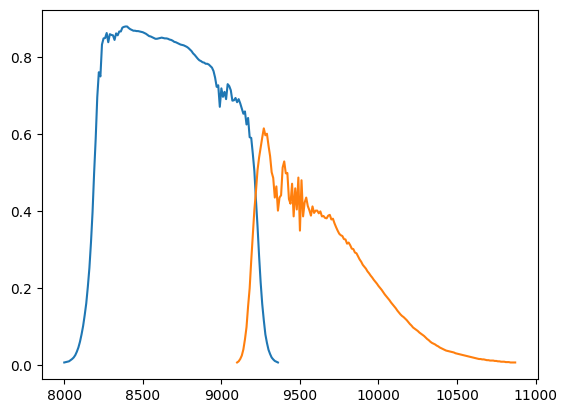

In [15]:
#Here we check the photometric bands available in SCULPTOR
pb_z = sod.PassBand(passband_name='PS1-z')
plt.plot(pb_z.dispersion, pb_z.fluxden)
pb_y = sod.PassBand(passband_name='PS1-y')
plt.plot(pb_y.dispersion, pb_y.fluxden)

## Re-scale data
The photometric points z_ab and H_band are used to re-scale our data to actual measures of the emission of the galaxy detected with other intruments.
Absolute flux 
In addition, we select the data we want to consider for our analysis, based on the noise of our data. For this we used mask mask_opt and mask,
for our optical data (GMOS) and near infrared data (F2) respectively.

In [16]:
## Note: Spec is flamingos(F2) and Spec2 is GMOS

#GMOS
#z band from PanSTARRS
z_ab = 20.5
pb_r = sod.PassBand('PS1-z')
nspecoptA = spec2.renormalize_by_ab_magnitude(z_ab, pb_r)


#Flamingos
#Absolute flux
H_band=19.70
pb_H = sod.PassBand(passband_name='2MASS-H')
nspecoptB=spec.renormalize_by_ab_magnitude(H_band,pb_H)


#Here we create masks to filter our datapoints / the ranges were test several times to avoid problematic areas
#Flamingos mask
mask= ((spec.dispersion > 14250) & (spec.dispersion < 18150)) | \
       ((spec.dispersion > 19300) & (spec.dispersion < 24200))
#print(len(mask))
print(len(spec.fluxden))

#GMOS mask
mask_opt= (
    (
        ((nspecoptA.dispersion > 6000) & (nspecoptA.dispersion < 8564)) | #8564
        ((nspecoptA.dispersion > 8673) & (nspecoptA.dispersion < 9660)) #9660
    ) 
)


1813


## Here we plot the data
 Original data in black and errors in gray and coloured data is the new normalized data

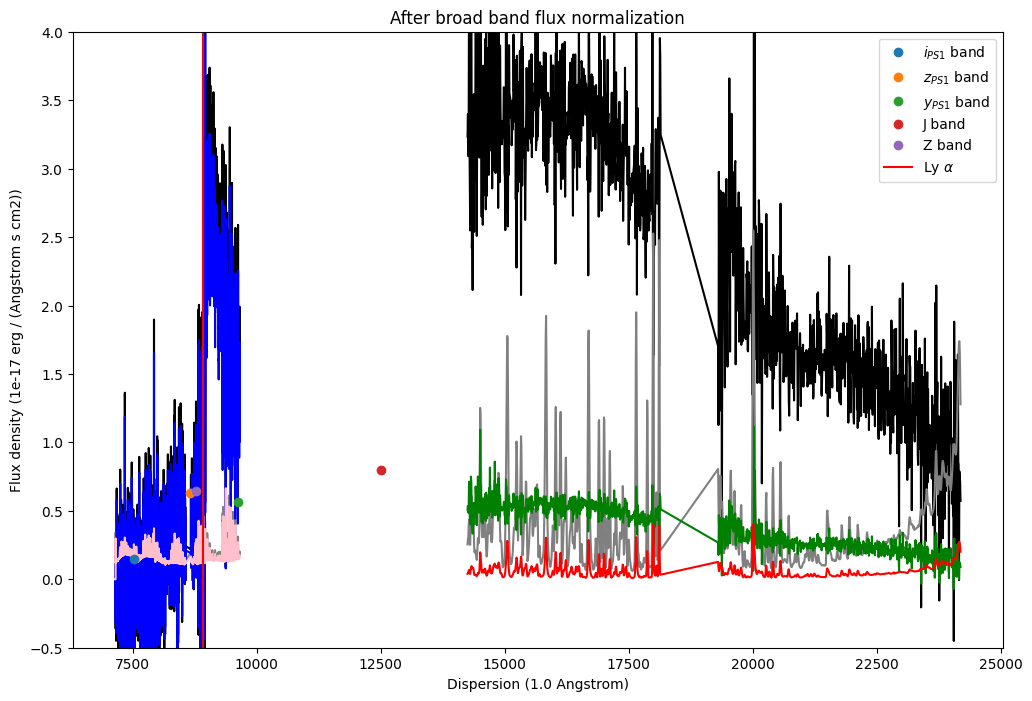

In [17]:
#Plot data   
plt.figure(figsize=(12, 8))
#F2 data before
plt.plot(spec.dispersion[mask], spec.fluxden[mask], 'black')
plt.plot(spec.dispersion[mask],spec.fluxden_err[mask], 'grey')

#F2 data after
plt.plot(nspecoptB.dispersion[mask], nspecoptB.fluxden[mask], 'green')
plt.plot(nspecoptB.dispersion[mask], nspecoptB.fluxden_err[mask], 'red')


#GMOS data before
plt.plot(spec2.dispersion[mask_opt], spec2.fluxden[mask_opt], 'black')
plt.plot(spec2.dispersion[mask_opt],spec2.fluxden_err[mask_opt], 'grey')
#GMOS data after
plt.plot(nspecoptA.dispersion[mask_opt], nspecoptA.fluxden[mask_opt], 'blue')
plt.plot(nspecoptA.dispersion[mask_opt],nspecoptA.fluxden_err[mask_opt], 'pink')


plt.xlabel('Dispersion ({})'.format(spec2.dispersion_unit))
plt.ylabel('Flux density ({})'.format(spec2.fluxden_unit))
plt.title('After broad band flux normalization')

#Plot some photometric points found in literature to check consistency and if they match our data
plt.plot(7520, 1.46e-1, 'o',label=r'$i_{PS1}$ band')
plt.plot(8660, 6.31e-1, 'o',label=r'$z_{PS1}$ band')
plt.plot(9620, 5.67e-1, 'o',label=r'$y_{PS1}$ band')
plt.plot(12500, 8.014e-1, 'o',label='J band')
plt.plot(8780, 6.47e-1, 'o',label='Z band')
plt.axvline(8924,color='red', label=r'Ly $\alpha$')
plt.ylim(-0.5,4)
plt.legend()


#Define again with filter to use in Sculptor
# OPT
nspecoptA=sod.SpecOneD(dispersion=nspecoptA.dispersion[mask_opt], fluxden=nspecoptA.fluxden[mask_opt], fluxden_ivar=nspecoptA.fluxden_err[mask_opt],
                   fluxden_unit=fluxden_unit, dispersion_unit=dispersion_unit, header=header)
# NIR
nspecoptB=sod.SpecOneD(dispersion=nspecoptB.dispersion[mask], fluxden=nspecoptB.fluxden[mask], fluxden_ivar=nspecoptB.fluxden_err[mask],
                   fluxden_unit=fluxden_unit, dispersion_unit=dispersion_unit, header=header) 


In [18]:
#We check some factors of the rescale data
nspecoptA = spec2.renormalize_by_ab_magnitude(z_ab, pb_r)
np.nanmean(nspecoptA.fluxden/spec2.fluxden)

/tmp/ipykernel_19827/1477695596.py:3: RuntimeWarning: invalid value encountered in divide
  np.nanmean(nspecoptA.fluxden/spec2.fluxden)


0.8710993555047282

## Here we re define data

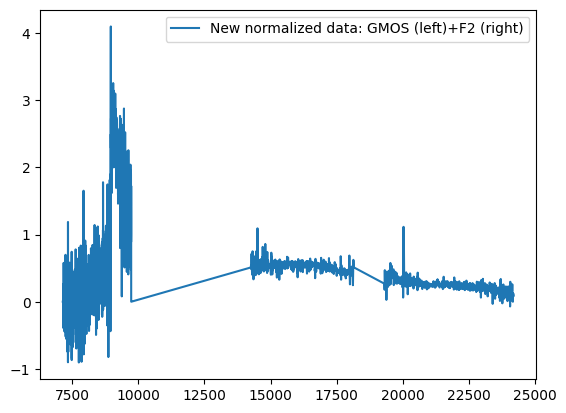

In [19]:
#Define new table with the new normalized data
tabs = astropy.table.Table()
tabs['WAVELENGTH']= np.append(nspecoptA.dispersion, nspecoptB.dispersion)
tabs['FLUX']= np.append(nspecoptA.fluxden, nspecoptB.fluxden)
tabs['ERR']= np.append(nspecoptA.fluxden_err,nspecoptB.fluxden_err) 
plt.plot(tabs['WAVELENGTH'],tabs['FLUX'],label='New normalized data: GMOS (left)+F2 (right)')
#print(np.min(tabs['FLUX']), np.max(tabs['FLUX']))
plt.legend()

## Middle step: Not used in final analysis since there is no need to do PL fit

In this part we perform a power law or PL fit, this was not used in the final analysis of the object since re-scale data with photometric point is enough. At the beggining we proceed with this PL fit since we obtain the H band point afterwards.  

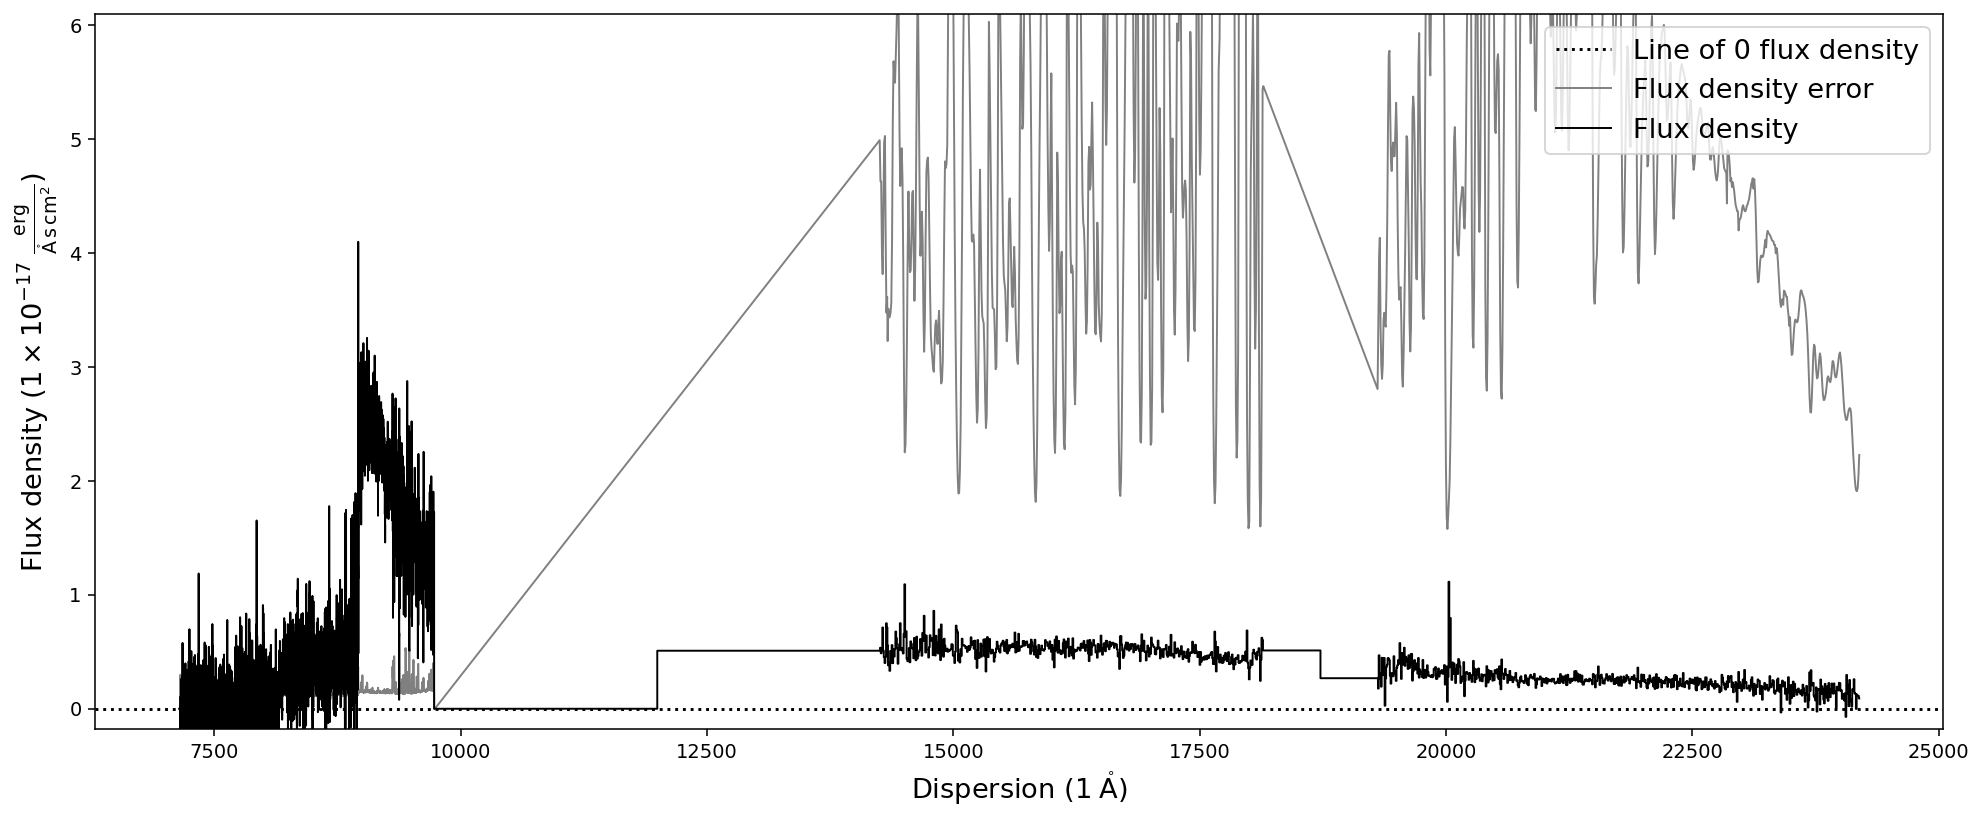

In [20]:
# Creation of a composite array in SCULPTOR 

dispersion_unit = 1.*units.AA
fluxden_unit = 1e-17 * units.erg/units.s/units.cm**2/units.AA
bool_nan = np.isnan(tabs["FLUX"].data) == False

#A step to eliminate zeros
trimmed_array = np.trim_zeros(tabs["FLUX"].data) #eliminate zeros
trimmed_array_err=np.trim_zeros(tabs["ERR"].data)

# Initialize a new SpecOneD object for the composite
composite = sod.SpecOneD(dispersion=tabs['WAVELENGTH'].data[bool_nan],
                        fluxden=tabs['FLUX'].data[bool_nan],
                        fluxden_err=(tabs['ERR'].data[bool_nan]),
                         # We now need to specify the physical units
                         # of the dispersion and flux density axis.
                         # Here, we simply copy them from the near-infrared
                         # spectrum.
                        dispersion_unit=dispersion_unit,
                        fluxden_unit=fluxden_unit)




# Let's plot our new composite spectrum
composite.plot(show_fluxden_err=True)

[INFO] Import "sculptor_extensions" package: my_extension
[INFO] Import "sculptor_extensions" package: qso
[WARNING] FeII iron template of Vestergaard & Wilkes 2001 NOT found. If you want to use the pre-defined iron models, please contact Marianne Vestergaard at mvester@nbi.ku.dk and add the Fe_UVtemplt_A.asc file to the sculptor/data/iron_templates folder.
[INFO] FeII iron template of Tsuzuki et al. 2006 found. If you will be using these templates in your model fit and publication, please add the citation to the original work, ADS bibcode: 2006ApJ...650...57T
[INFO] FeII iron template of Boroson & Green 1992 found. If you will be using these templates in your model fit and publication, please add the citation to the original work, ADS bibcode: 1992ApJS...80..109B
[INFO] Manual mask range 14000 18300
[INFO] Manual mask range 19000 24700


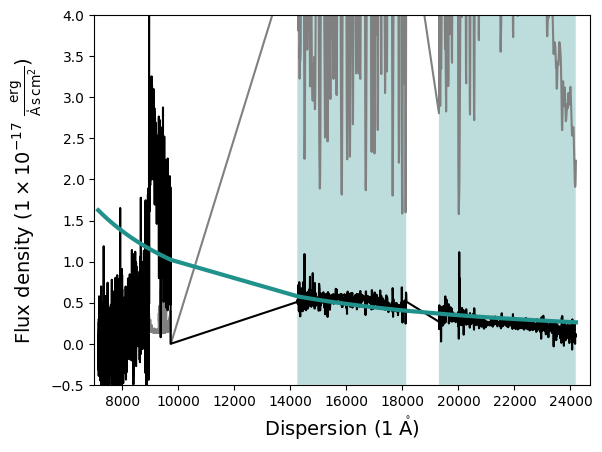

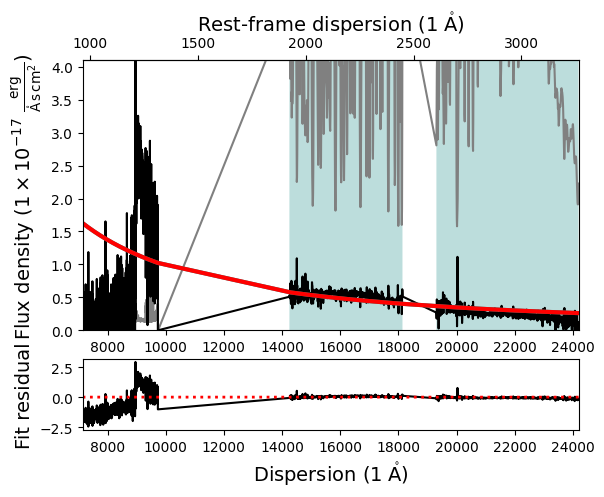

In [21]:
from sculptor import specfit as scfit
from sculptor import specmodel as scmod
import pkg_resources
redshift = 6.41 #First redshift published for the object / Banados et al., 2023

# Plot the quasar spectrum for confirmation that everything worked well.
fit = scfit.SpecFit(composite, redshift)

# Add the continuum SpecModel
fit.add_specmodel()
# We access the initialized SpecModel object by using the first item in the SpecFit.specmodels list
contmodel = fit.specmodels[0]
# Let us rename this SpecModel 'Continuum'
contmodel.name = 'Continuum'

# Define the model function name
model_name = 'Power Law (2500A)'
# Define the model prefix
# It is important to keep track of the prefix to later access this model in the analysis
model_prefix = 'PL_'
# Add the model function to the SpecModel
contmodel.add_model(model_name, model_prefix)
params = contmodel.params_list[0]
params['PL_slope'].vary = False #We wanted a set slope

#Here you can define continuum models to mask for the fit
contmodel.add_wavelength_range_to_fit_mask(14000, 18300)
contmodel.add_wavelength_range_to_fit_mask(19000, 24700)
# Fit the continuum model
contmodel.fit()
# Plot the fitted continuum model and the spectrum
contmodel.plot(xlim=[7000, 24700], ylim=[-0.5, 4])
#contmodel.ylim([0,6])
# Plot the SpecFit fit with all SpecModels (We only have 1 at the moment)
fit.plot()

In [22]:
#Here we can save and check the results of the fit. The values for slope, amplitude and redshift.
#fit.save('example_fit_cont')
contmodel.fit_result

We fixed the PL to be -1.5 because most quasars show that measure

In [23]:
#We import two different datasets with other photometric points from other infrared facilities since we think they could be useful for our analysis
#Generated txt file show the W1 and W2 points for our object
from astropy.table import Table
leg10=Table.read('aurora_leg.txt',format='ascii')
leg10.columns
print(leg10['mag_w1'],leg10['mag_w2'])
leg10['snr_w2'],leg10['snr_w1']

  mag_w1 
---------
20.299019   mag_w2 
---------
20.877861


(<Column name='snr_w2' dtype='float64' length=1>
 3.8486402,
 <Column name='snr_w1' dtype='float64' length=1>
 15.245079)

# Template testing
In this part we first explore the templates from quasars and then the brown dwarf to choose which one we will use for out final model.
Four our analysis we used several templates of distant galaxies characterized for big bump on a wavelenght rest-frame 1215 angstroms called Lyman alpha.

### Quasar templates: Selsing

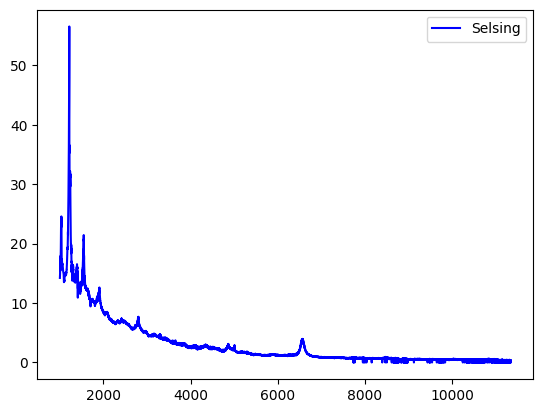

In [24]:
#Quasar template Selsing et al., 2015
data = np.loadtxt('Selsing2015.dat', delimiter=' ')
wl=data[:,0]
weighted_mean=data[:,1]
error_of_weighted_mean=data[:,2]
plt.plot(wl,weighted_mean, color='blue',label='Selsing')
plt.legend()

### Quasar templates: Banados

<Table length=960>
    name     dtype   unit                 description                
----------- ------- ------ ------------------------------------------
       Wave float64 0.1 nm                    Wavelength in Angstroms
      FluxD float64     --        Flux density PS1 composite spectrum
          N   int64     --       Number of quasars per wavelength bin
FluxD(hlya) float64     -- Flux density strong lya composite spectrum
FluxD(llya) float64     --   Flux density weak lya composite spectrum


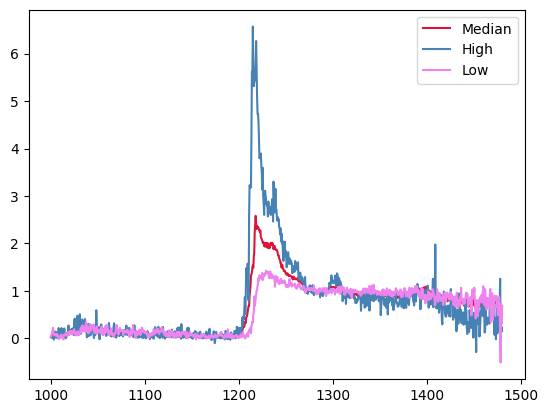

In [25]:
#Templates of high-z quasars from Banados et al., (2016)
compositehrspectra=Table.read('compositespectra.txt',format='ascii')
compositehrspectra.info()
composite_flux=compositehrspectra['FluxD']
composite_fluxhl=compositehrspectra['FluxD(hlya)']
composite_fluxll=compositehrspectra['FluxD(llya)']
composite_wave=compositehrspectra['Wave']
#Plot templates to see the shape
plt.plot(composite_wave,composite_flux, label="Median",color='crimson')
plt.plot(composite_wave,composite_fluxhl, label= "High",color='steelblue')
plt.plot(composite_wave,composite_fluxll, label="Low",color='violet')
plt.legend()

In [36]:
#Final wavelegth to Banados data / This will be important later in the analysis to join templates
composite_wave[0],composite_wave[-1]

(1000.0, 1479.5)

### Median Lyman-alpha

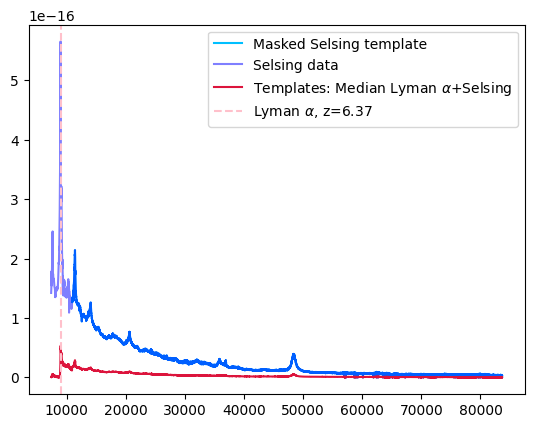

In [26]:
#Join Composite median Banados+Selsing et el., (2015) data
z=6.37 #This is the redshift of the galaxy in a preliminary test using astronomical software] 

#To shift the templates from rest-frame to the galaxy redshift is necessary to multiply wavelength for (z+1) factor,
#whereas the flux is divided for this factor.

#Mask  to match templates
maskcs=wl>1479.5 #Here to the last Banados wave 
selsingflux=weighted_mean[maskcs]

#Here we joined both templates doing an average of a small region of 100 angstroms to merge data
#Here we took the first template composite_flux or medial Lyalpha
mask_sel=(wl>1300)&(wl<1400) 
mask_totalc=(composite_wave>1300)&(composite_wave<1400) 
#Average for comp and selsing
av_qso_comp=np.mean(weighted_mean[mask_sel])
av_data=np.mean(composite_flux[mask_totalc])
factorc=av_qso_comp/av_data
############ 

#Create table with our final data
tabc = astropy.table.Table()
tabc['WAVE']= np.append((z+1)*composite_wave,(z+1)*wl[maskcs])
tabc['FLUX']= np.append(composite_flux*1e-17*factorc/(z+1),1e-17*selsingflux/(z+1))
#Plot templates
plt.plot((z+1)*wl[maskcs],1e-17*selsingflux,label='Masked Selsing template',color='deepskyblue',zorder=0)
plt.plot((z+1)*wl,1e-17*weighted_mean,label='Selsing data',color='blue',alpha=0.5)
plt.plot(tabc['WAVE'],tabc['FLUX'], label=r'Templates: Median Lyman $\alpha$+Selsing',color='crimson')
plt.axvline(1215.67*(z+1), linestyle='--',label=r'Lyman $\alpha$, z=6.37',color='pink')
plt.legend()

### High Lyman-alpha

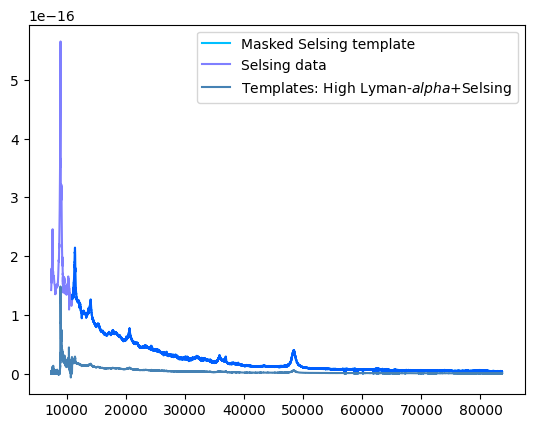

In [27]:
#Composite Banados HLyA+Selsing data
z=6.37
data = np.loadtxt('Selsing2015.dat', delimiter=' ')
wl=data[:,0]
weighted_mean=data[:,1]
error_of_weighted_mean=data[:,2]

#last wavelenght 1479.5
maskcs=wl>1479.5
selsingflux=weighted_mean[maskcs]

#Here we joined both templates doing an average of a small region of 100 angstroms to merge data
#Here we took the first template composite_flux or highl Lyalpha
#Average for comp  
mask_sel = (wl > 1300) & (wl < 1400)
mask_totalc = (composite_wave > 1300) & (composite_wave < 1400)
av_data_h=np.mean(composite_fluxhl[mask_totalc])
factorch=av_qso_comp/av_data_h


#Create table to save data
tabch = astropy.table.Table()
tabch['WAVE']= np.append((z+1)*composite_wave,(z+1)*wl[maskcs])
tabch['FLUX']= np.append((composite_fluxhl*1e-17*factorch)/(z+1),1e-17*selsingflux/(z+1))

#Here plot data
plt.plot((z+1)*wl[maskcs],1e-17*selsingflux,label='Masked Selsing template',color='deepskyblue',zorder=0)
plt.plot((z+1)*wl,1e-17*weighted_mean,label='Selsing data',color='blue',alpha=0.5)
plt.plot(tabch['WAVE'],tabch['FLUX'],label=r'Templates: High Lyman-$alpha$+Selsing',color='steelblue')
plt.legend()

### Low Lyman-alpha

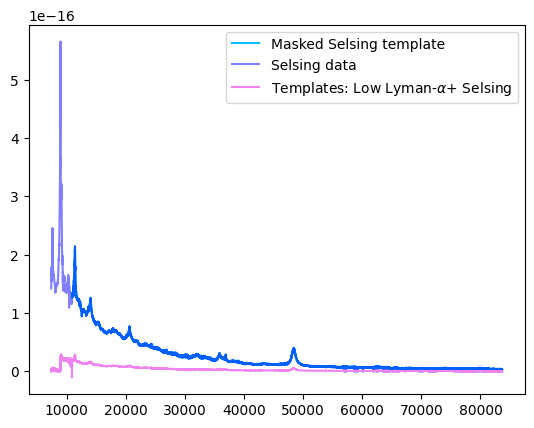

In [28]:
#Last template low lyman
#Composite Banados LLyA+Selsing data
z=6.37
data = np.loadtxt('Selsing2015.dat', delimiter=' ')
wl=data[:,0]
weighted_mean=data[:,1]
error_of_weighted_mean=data[:,2]

#last wavelenght 1479.5
maskcs=wl>1479.5
selsingflux=weighted_mean[maskcs]

#Average
mask_sel = (wl > 1300) & (wl < 1400)
mask_totalc = (composite_wave > 1300) & (composite_wave < 1400)
av_data_l=np.mean(composite_fluxll[mask_totalc])
factorcl=av_qso_comp/av_data_l


#Save data to table
tabcl = astropy.table.Table()
tabcl['WAVE']= np.append((z+1)*composite_wave,(z+1)*wl[maskcs])
tabcl['FLUX']= np.append((composite_fluxll*1e-17*factorcl)/(z+1),1e-17*selsingflux/(z+1))
#Plot data
plt.plot((z+1)*wl[maskcs],1e-17*selsingflux,label='Masked Selsing template',color='deepskyblue',zorder=0)
plt.plot((z+1)*wl,1e-17*weighted_mean,label='Selsing data',color='blue',alpha=0.5)
plt.plot(tabcl['WAVE'],tabcl['FLUX'], label=r'Templates: Low Lyman-$\alpha$+ Selsing',color='violet')
plt.legend()

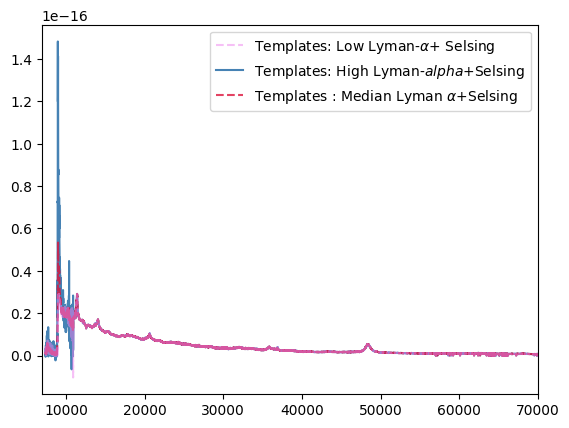

In [29]:
#Plot together complete templates
plt.plot(tabcl['WAVE'],tabcl['FLUX'], label=r'Templates: Low Lyman-$\alpha$+ Selsing',linestyle='--',alpha=0.5,color='violet',zorder=2)
plt.plot(tabch['WAVE'],tabch['FLUX'],label=r'Templates: High Lyman-$alpha$+Selsing',color='steelblue',zorder=0)
plt.plot(tabc['WAVE'],tabc['FLUX'], label=r'Templates : Median Lyman $\alpha$+Selsing',linestyle='--',alpha=0.8,color='crimson',zorder=1)
plt.xlim(6900,70000)
plt.legend()

### Here we plot the  data, quasar templates and photometric points reported in literature

/tmp/ipykernel_19827/190714101.py:12: RuntimeWarning: divide by zero encountered in divide
  ax1.plot(nspecoptA.dispersion[mask_opt],1e-17/(nspecoptA.fluxden_ivar[mask_opt])**2, 'grey')


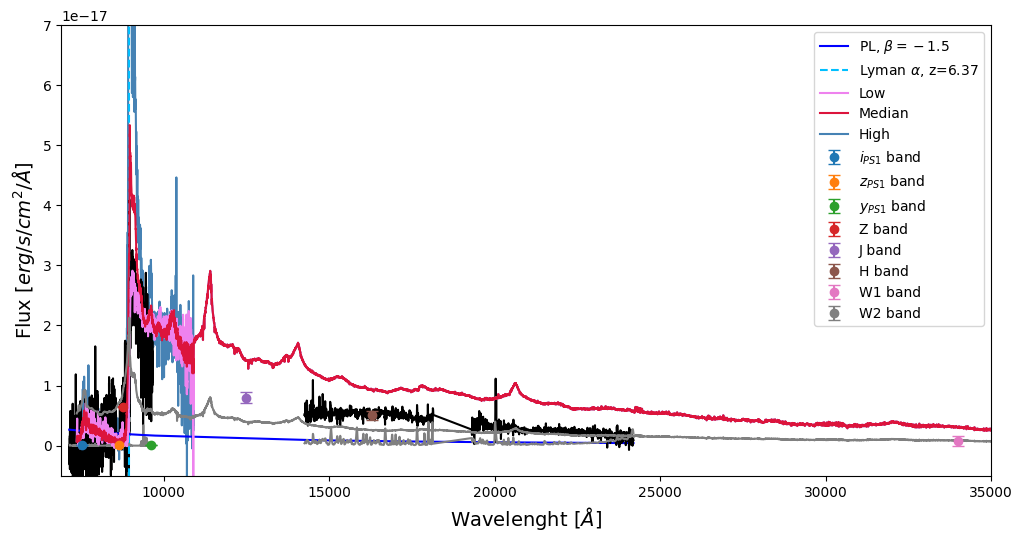

In [34]:
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
fig = plt.figure(figsize=(12, 8))


##Build plot
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax1 = fig.add_subplot(gs[0])

#Plotting data
ax1.plot(nspecoptA.dispersion[mask_opt], nspecoptA.fluxden[mask_opt]*1e-17, 'black')
ax1.plot(nspecoptA.dispersion[mask_opt],1e-17/(nspecoptA.fluxden_ivar[mask_opt])**2, 'grey')

#Fitting flamingos
#factorflamingos=6.1 #6
factorpl=6.1

#Plotting PL (this power law is not used in final analysis)
ax1.plot(contmodel.spec.dispersion,1e-17*fit.specmodels[0].model_fluxden/factorpl,color='blue',label=r'PL, $\beta=-1.5$')

#Plotting FLAMINGOS
ax1.plot(nspecoptB.dispersion, 1e-17*nspecoptB.fluxden, 'black')
ax1.plot(nspecoptB.dispersion, 1e-17/(nspecoptB.fluxden_err)**2, 'grey')

#Plotting different points
#PanSTARRS photometric points
ax1.errorbar(x=7520, y=8.15e-20, yerr=2.5e-20, fmt='o', capsize=4,label=r'$i_{PS1}$ band')
ax1.errorbar(x=8660, y=1.67e-19, yerr=0.05e-19, fmt='o', capsize=4,label=r'$z_{PS1}$ band')
ax1.errorbar(x=9620, y=1.77e-19, yerr=0.1e-19, fmt='o', capsize=4,label=r'$y_{PS1}$ band')
#Other bands
ax1.errorbar(x=8780, y=6.47e-18, yerr=0.11e-18, fmt='o', capsize=4,label='Z band')
ax1.errorbar(x=12500, y=8.014e-18, yerr=0.85e-18, fmt='o', capsize=4,label='J band')
ax1.errorbar(x=16300, y=5.04e-18, yerr=0.8e-18, fmt='o', capsize=4,label='H band')
#Wise points
ax1.errorbar(x=34000, y=7.19e-19, yerr=0.85e-18, fmt='o', capsize=4,label='W1 band')
ax1.errorbar(x=46000, y=2.28e-19, yerr=0.8e-18, fmt='o', capsize=4,label='W2 band')

ax1.set_ylabel(r'Flux [$erg/s/cm^2/\AA$]',fontsize=14)
ax1.set_xlabel(r'Wavelenght [$\AA$]',fontsize=14)


#QSO template

mask_t= wl >1215.67 
factor=1#4.7
flux_QSO=1e-17*(weighted_mean)/((z+1)*factor)

#Plotting Lya
ax1.axvline(1215.67*(z+1), linestyle='--',label=r'Lyman $\alpha$, z=6.37',color='deepskyblue')


#Just plotting different quassar templates
ax1.plot(tabcl['WAVE'],tabcl['FLUX'],label='Low',color='violet')
ax1.plot(tabc['WAVE'],tabc['FLUX'],label='Median',color='crimson')
ax1.plot(tabch['WAVE'],tabch['FLUX'],label='High',color='steelblue',zorder=0)

ax1.plot(wl*(1+z),(1e-17*weighted_mean/(1+z))/3.6,color='gray')

ax1.set_xlim(6900,35000)
ax1.set_ylim(-0.5*1e-17, 7*1e-17)

#ax1.set_xscale('log')
plt.legend()


From the last image we can see that using the PL gives a really low value for F2, this is why it was decided to use the H-band after we got acess to the photometric point (brown).
PS1 points shows no detections.
Appears that Low Lyman follows the Lyman alpha region but after fitting to the data, Median Lyman was the best fit for that region.


In [31]:
#Final array - GMOS was rescale to z-ps1 and F2 to H band

tabf = astropy.table.Table()
tabf['WAVELENGTH']= np.append(nspecoptA.dispersion,nspecoptB.dispersion)
tabf['FLUX']=np.append(nspecoptA.fluxden*1e-17,(nspecoptB.fluxden)*1e-17)
tabf['ERR']= np.append(1e-17*(nspecoptA.fluxden_err)**2, 1e-17/(nspecoptB.fluxden_err)**2) 

#Write the new array / used for analysis
#tabf.write('spectra_gmos_fla_2_v2.txt', format='ascii', overwrite=True)

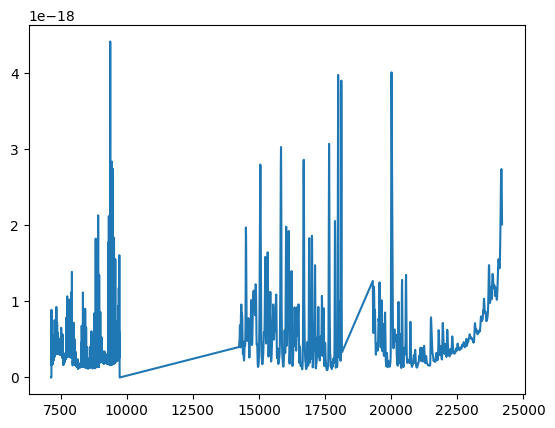

In [32]:
#Check if error vector looks ok for both datasets
plt.plot(tabf['WAVELENGTH'],tabf['ERR'])

# Brown dwarf templates
For our analysis we used brown dwarf templates, for Burgasser & Elwain et al.,2015 .

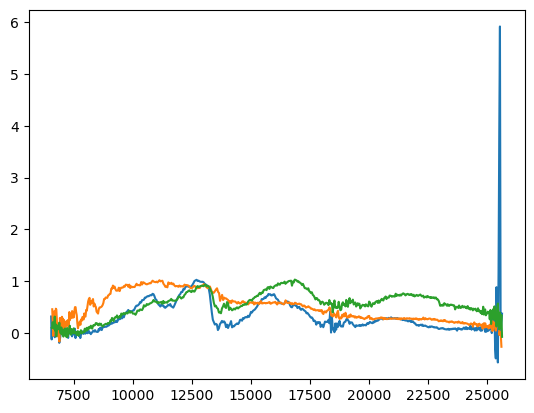

In [28]:
#Some BD
brownd_t=Table.read('2MASSJ11220826m351236320040312BUR06C',format='ascii')
brownd_t.columns
plt.plot(brownd_t['col1']*1e4,brownd_t['col2'])


brownd_m=Table.read('2MASSJ00013044p101014620030919BUR04B',format='ascii')
brownd_m.columns
plt.plot(brownd_m['col1']*1e4,brownd_m['col2'])

brownd_l=Table.read('2MASSIJ0103320p19353620030919CRU04A',format='ascii')
brownd_l.columns
plt.plot(brownd_l['col1']*1e4,brownd_l['col2'])

## From here only brown dwarfs
The process with brown dwarf fitting to our data was made by plotting our data and masking a small region in both datasets (data and brown dwarf template) and then doing an average. This average was used to reescale data and see the best fit of all the templates of brown dwarfs.
Images are not included in the notebook to save space for the git version.

### M dwarf

In [36]:
# #Only M
# fig = plt.figure(figsize=(12, 8))


# tabf = astropy.table.Table()
# tabf['WAVELENGTH']= np.append(nspecoptA.dispersion[mask_opt],spec.dispersion[mask])
# tabf['FLUX']= np.append(filtered_arr*1e-17,1e-17*filtered_arr2)
# tabf['ERR']= np.append(1e-17/(filtered_arr_err)**2, 1e-17*filtered_arr_err2) 


# mask_bd=(wl>1215.67)# &(wl*(z+1)<9900)|(wl*(z+1)>14000) & (wl*(z+1)<18300)|(wl*(z+1)>19000) &   (wl*(z+1)<24900)
# a=tabf['FLUX']
# b=flux_QSO[mask_bd]
# #resultado =  [x - y for x, y in zip_longest(a, b, fillvalue=0)]
# min_len = min(len(a), len(b))
# resultado = a[:min_len] - b[:min_len]

# #plt.plot(tabf['WAVELENGTH'],a,label='Object spectra')
# plt.plot(tabf['WAVELENGTH'],resultado,label='Subtraction Object-QSO')
# #plt.plot((z+1)*(wl[mask_t]),flux_QSO,label='QSO template')



# plt.errorbar(x=16300, y=5.04e-18, yerr=0.8e-18, fmt='o', capsize=4,label='H band')
# plt.errorbar(x=12500, y=8.014e-18, yerr=0.85e-18, fmt='o', capsize=4,label='J band')

# #PLOT OTHER bd m STARS

# factorm=1.22 #This is not used in the final analysis, it was a way to test how the template fit the data

# plt.plot(brownd_m['col1']*1e4,brownd_m['col2']*1e-17/factorm,label='BD M')
# brownd_t2=Table.read('2MASSJ00115060m152345020030918BUR04B',format='ascii')
# brownd_m2.columns
# plt.plot(brownd_m2['col1']*1e4,brownd_m2['col2']*1e-17/factorm,label='BD M2')

# brownd_m3=Table.read('2MASSJ1237p302820080618SHE09A',format='ascii')
# brownd_m3.columns
# plt.plot(brownd_m3['col1']*1e4,brownd_m3['col2']*1e-17/factorm,label='BD M3')
# plt.xscale('log')

# plt.xlim(7000,25000)
# plt.legend()

### T dwarf

In [ ]:
# #Only t
# from itertools import zip_longest
# fig = plt.figure(figsize=(12, 8))


# tabf = astropy.table.Table()
# tabf['WAVELENGTH']= np.append(nspecoptA.dispersion[mask_opt],spec.dispersion[mask])
# tabf['FLUX']= np.append(filtered_arr*1e-17,1e-17*filtered_arr2)
# tabf['ERR']= np.append(1e-17/(filtered_arr_err)**2, 1e-17*filtered_arr_err2) 


# mask_bd=(wl>1215.67)# &(wl*(z+1)<9900)|(wl*(z+1)>14000) & (wl*(z+1)<18300)|(wl*(z+1)>19000) &   (wl*(z+1)<24900)
# a=tabf['FLUX']
# b=flux_QSO[mask_bd]
# #resultado =  [x - y for x, y in zip_longest(a, b, fillvalue=0)]
# min_len = min(len(a), len(b))
# resultado = a[:min_len] - b[:min_len]

# #plt.plot(tabf['WAVELENGTH'],a,label='Object spectra')
# plt.plot(tabf['WAVELENGTH'],resultado,label='Subtraction Object-QSO')
# plt.plot((z+1)*(wl[mask_t]),flux_QSO[mask_t],label='QSO template')

# #plt.plot(brownd_m['col1']*1e4,brownd_m['col2']*1e-17/1.1,label='BD M')
# #plt.plot(brownd_l['col1']*1e4,brownd_l['col2']*1e-17/1.2,label='BD l')
# plt.errorbar(x=12500, y=8.014e-18, yerr=0.85e-18, fmt='o', capsize=4,label='J band')
# plt.errorbar(x=16300, y=5.04e-18, yerr=0.8e-18, fmt='o', capsize=4,label='H band')

# #PLOT OTHER bd m STARS
# factort=1.2
# plt.plot(brownd_t['col1']*1e4,brownd_t['col2']*1e-17/factort,label='BD T')
# brownd_t2=Table.read('2MASSJ13243553p635828120060411LOO07A',format='ascii')
# plt.plot(brownd_t2['col1']*1e4,brownd_t2['col2']*1e-17/factort,label='BD T2')

# brownd_t3=Table.read('HD3651B20060903BUR07B',format='ascii')
# plt.plot(brownd_t3['col1']*1e4,brownd_t3['col2']*1e-17/factort,label='BD T3')
# plt.xscale('log')

# plt.xlim(7000,25000)
# plt.legend()

### L dwarf

In [ ]:
# #Only l
# from itertools import zip_longest
# fig = plt.figure(figsize=(12, 8))


# tabf = astropy.table.Table()
# tabf['WAVELENGTH']= np.append(nspecoptA.dispersion[mask_opt],spec.dispersion[mask])
# tabf['FLUX']= np.append(filtered_arr*1e-17,1e-17*filtered_arr2)
# tabf['ERR']= np.append(1e-17/(filtered_arr_err)**2, 1e-17*filtered_arr_err2) 


# mask_bd=(tabf['WAVELENGTH']>8959.4879)# &(wl*(z+1)<9900)|(wl*(z+1)>14000) & (wl*(z+1)<18300)|(wl*(z+1)>19000) &   (wl*(z+1)<24900)
# a=tabf['FLUX']
# b=flux_QSO[wl>1215.670*(z+1)]

# #resultado =  [x - y for x, y in zip_longest(a, b, fillvalue=0)]
# min_len = min(len(a), len(b))
# resultado = a[:min_len] - b[:min_len]

# #plt.plot(tabf['WAVELENGTH'],a,label='Object spectra')
# plt.plot(tabf['WAVELENGTH'],resultado,label='Subtraction Object-QSO')
# plt.plot((z+1)*(wl[mask_t]),flux_QSO[mask_t],label='QSO template')


# plt.errorbar(x=12500, y=8.014e-18, yerr=0.85e-18, fmt='o', capsize=4,label='J band')
# plt.errorbar(x=16300, y=5.04e-18, yerr=0.8e-18, fmt='o', capsize=4,label='H band')

# #PLOT OTHER bd L STARS
# factorl=1.7
# plt.plot(brownd_l['col1']*1e4,brownd_l['col2']*1e-17/factorl,label='BD L')
# brownd_l2=Table.read('2MASSJ01414839m160119620051018KIR10A',format='ascii')
# plt.plot(brownd_l2['col1']*1e4,brownd_l2['col2']*1e-17/factorl,label='BD L2')

# brownd_l3=Table.read('2MASSJ05161597m333204620041107BUR10A',format='ascii')
# plt.plot(brownd_l3['col1']*1e4,brownd_l3['col2']*1e-17/factorl,label='BD L3')


# plt.xlim(7000,30000)
# plt.legend()
# plt.xscale('log')